# Hypothesis Testing

The purpose of the test is to tell if there is any significant difference between two data sets.



## Overview

This module covers,

1) One sample and Two sample t-tests

2) ANOVA

3) Type I and Type II errors

4) Chi-Squared Tests

## Question 1 

*A student is trying to decide between two GPUs. He want to use the GPU for his research to run Deep learning algorithms, so the only thing he is concerned with is speed.*


*He picks a Deep Learning algorithm on a large data set and runs it on both GPUs 15 times, timing each run in hours. Results are given in the below lists GPU1 and GPU2.*

In [25]:
from scipy import stats 
import numpy as np

In [26]:
GPU1 = np.array([11,9,10,11,10,12,9,11,12,9,11,12,9,10,9])
GPU2 = np.array([11,13,10,13,12,9,11,12,12,11,12,12,10,11,13])
mu1 = np.mean(GPU1)
print(mu1)
#Assumption: Both the datasets (GPU1 & GPU 2) are random, independent, parametric & normally distributed

10.333333333333334


Hint: You can import ttest function from scipy to perform t tests 

**First T test**

*One sample t-test*

Check if the mean of the GPU1 is equal to zero.
- Null Hypothesis is that mean is equal to zero.
- Alternate hypothesis is that it is not equal to zero.

In [27]:
from scipy.stats import ttest_1samp
pvalue = ttest_1samp(GPU1, 0)
print(pvalue)

#pvalue is less than 5% level of significance so the statistical decision is to reject the null hypothesis
# at 5% level of significance
# So there is sufficient evidence to prove that GPU1 mean is not equal to 0  

Ttest_1sampResult(statistic=34.056241516158195, pvalue=7.228892044970457e-15)


## Question 2

Given,

Null Hypothesis : There is no significant difference between data sets

Alternate Hypothesis : There is a significant difference

*Do two-sample testing and check whether to reject Null Hypothesis or not.*

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

In [28]:
from scipy.stats import ttest_ind


pvalue = ttest_ind(GPU1, GPU2)
print(pvalue)


#pvalue is less than 5% level of significance so the statistical decision is to reject the null hypothesis
# at 5% level of significance
# So there is sufficient evidence to prove that  there is a significant difference between speeds of GPU1 and GPU2

Ttest_indResult(statistic=-2.627629513471839, pvalue=0.013794282041452725)


## Question 3

He is trying a third GPU - GPU3.

In [29]:
GPU3 = np.array([9,10,9,11,10,13,12,9,12,12,13,12,13,10,11])

#Assumption: Both the datasets (GPU1 & GPU 3) are random, independent, parametric & normally distributed

*Do two-sample testing and check whether there is significant differene between speeds of two GPUs GPU1 and GPU3.*

#### Answer:

In [30]:
#1. H0: mu1 = mu3
#   HA: mu1 Not= mu3

pvalue = ttest_ind(GPU1, GPU3)
print(pvalue)

#pvalue is more than 5% level of significance so the statistical decision is we fail to reject the null hypothesis
# at 5% level of significance
# So there is not sufficient evidence to prove that  there is a significant difference between speeds of GPU1 and GPU3 and
#status quo of mean speed being equal for GPU1 and GPU3 is maintained 

Ttest_indResult(statistic=-1.4988943759093303, pvalue=0.14509210993138993)


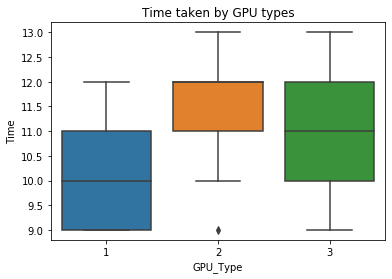

C:\Users\DELL\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\DELL\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


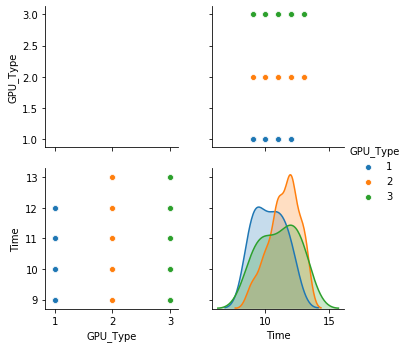

In [31]:
#validate by plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
GPU_df = pd.DataFrame()

df1            = pd.DataFrame({'GPU_Type': 1, 'Time':GPU1})
df2            = pd.DataFrame({'GPU_Type': 2, 'Time':GPU2})
df3            = pd.DataFrame({'GPU_Type': 3, 'Time':GPU3})

GPU_df = GPU_df.append(df1) 
GPU_df = GPU_df.append(df2) 
GPU_df = GPU_df.append(df3) 

GPU_df


sns.boxplot(x = "GPU_Type", y = "Time", data = GPU_df)
plt.title('Time taken by GPU types')
plt.show()
sns.pairplot(GPU_df,diag_kind='kde',hue='GPU_Type')

## ANOVA

## Question 4 

If you need to compare more than two data sets at a time, an ANOVA is your best bet. 

*The results from three experiments with overlapping 95% confidence intervals are given below, and we want to confirm that the results for all three experiments are not significantly different.*

But before conducting ANOVA, test equality of variances (using Levene's test) is satisfied or not. If not, then mention that we cannot depend on the result of ANOVA

In [32]:
import numpy as np

e1 = np.array([1.595440,1.419730,0.000000,0.000000])
e2 = np.array([1.433800,2.079700,0.892139,2.384740])
e3 = np.array([0.036930,0.938018,0.995956,1.006970])

#Assumption: All the 3 datasets (e1,e2 & e3) are random, independent, parametric & normally distributedz


Perform levene test on the data

The Levene test tests the null hypothesis that all input samples are from populations with equal variances. Levene’s test is an alternative to Bartlett’s test bartlett in the case where there are significant deviations from normality.

source: scipy.org

#### Answer:

In [33]:
#For ANOVA data should be random, independent, normal and variances across groups should be equal
# Randomness, independence and normality has been assumed in problem statement
# Precondition of equal variance is checked through Levene's Test
#LEVENE's TEST H0: Variances are equal
#LEVENE's TEST HA: Variances are not equal
from scipy.stats import levene
pvalue = levene(e1, e2, e3, center='mean') #For normal distribution center is mean

print(pvalue)
#pvalue is greater than alpha = 0.05 so we fail to reject the null so "variances are equal" holds true
#Thus ANOVA test is reliable

#pvalue is more than 5% level of significance so the statistical decision is we fail to reject the null hypothesis
# at 5% level of significance
# So there is not sufficient evidence to prove that  there is a significant difference between variances and
#status quo ofvariances are equal is maintained 

LeveneResult(statistic=3.8188429894002014, pvalue=0.06297571955563695)



## Question 5

The one-way ANOVA tests the null hypothesis that two or more groups have the same population mean. The test is applied to samples from two or more groups, possibly with differing sizes.

use stats.f_oneway() module to perform one-way ANOVA test

In [34]:
#Null Hypothesis H0:three groups e1, e2, e3 have same population mean
#Alternate Hypothesis HA: At least one of the populations have different mean
from scipy.stats import f_oneway
statistic, pvalue = f_oneway(e1, e2, e3)
print(statistic)
print(pvalue)

#pvalue is more than 5% level of significance so the statistical decision is we fail to reject the null hypothesis
# at 5% level of significance
# So there is not sufficient evidence to prove that  one of the population means is different  and
#status quo of three groups having same population mean is maintained 

2.51357622845924
0.13574644501798466


In [35]:
#Trying alternate way of calculating anova

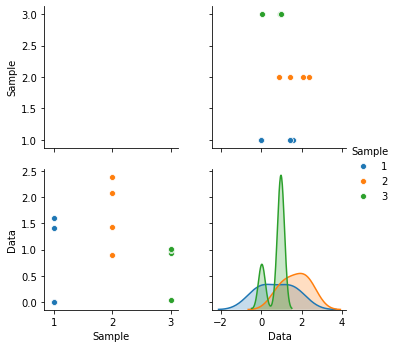

In [36]:
#validate results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df1 = pd.DataFrame({"Sample":1, "Data":e1})
df2 = pd.DataFrame({"Sample":2, "Data":e2})
df3 = pd.DataFrame({"Sample":3, "Data":e3})
final_df = pd.DataFrame()
final_df = final_df.append(df1)
final_df = final_df.append(df2)
final_df = final_df.append(df3)

final_df.head()
sns.pairplot(final_df, diag_kind='kde',hue='Sample')


## Question 6

*In one or two sentences explain about **TypeI** and **TypeII** errors.*

#### Answer:

In [37]:
# Type 1 errors (denoted by alpha) are those errors when NULL hypothesis is actually true but we Reject the null. For example in   
# a court case, we send an innocent person to jail by rejecting the null hypothesis of "Person is innocent"
# Type 2 errors (denoted by beta) arise in those conditions when NULL Hypothesis is not true but we donot reject the NULL. With
# reference to court case example it indicates we treat criminal as innocent

## Question 7 

You are a manager of a chinese restaurant. You want to determine whether the waiting time to place an order has changed in the past month from its previous population mean value of 4.5 minutes. 
State the null and alternative hypothesis.




In [38]:
#### Answer:
#  H0 : mu = 4.5 [Mean waiting time is equal to 4.5]
# HA : mu not equal to 4.5 [Mean waiting time is greater or less than 4.5]

#I am assuming that manager wants to know if waiting time has reduced(desirable) or increased(not desirable).
#2tailed onesample test

## Chi square test

## Question 8

Let's create a small dataset for dice rolls of four players

In [39]:
import numpy as np

d1 = [5, 8, 3, 8]
d2 = [9, 6, 8, 5]
d3 = [8, 12, 7, 2]
d4 = [4, 16, 7, 3]
d5 = [3, 9, 6, 5]
d6 = [7, 2, 5, 7]

dice = np.array([d1, d2, d3, d4, d5, d6])

run the test using SciPy Stats library

Depending on the test, we are generally looking for a threshold at either 0.05 or 0.01. Our test is significant (i.e. we reject the null hypothesis) if we get a p-value below our threshold.

For our purposes, we’ll use 0.01 as the threshold.

use stats.chi2_contingency() module 

This function computes the chi-square statistic and p-value for the hypothesis test of independence of the observed frequencies in the contingency table

Print the following:

- chi2 stat
- p-value
- degree of freedom
- contingency



In [40]:
#null hypothesis there is no significant difference between obsserved and expected frequencies  
#alternate hypothesis is there is significant difference between observed and expected frequencies
from scipy.stats import chi2_contingency
chi2_stat, p_val, dof, cont = chi2_contingency(dice)
print("Chi 2 stat is")
print(chi2_stat)
print("\n")
print("p value is")
print(p_val)
print("\n")
print("Degree of freedom is")
print(dof)
print("\n")
print("contingency is")
print(cont)
print("\n")
#Alpha threshold for critical value is 0.01
#p value is 0.0776 and it is greater than 1% level of significance
#so the statistical decision is tht we fail to reject the null hypothesis at 1% level of significance. so status 
#quo of no significant difference is maintained

Chi 2 stat is
23.315671914716496


p value is
0.07766367301496693


Degree of freedom is
15


contingency is
[[ 5.57419355  8.20645161  5.57419355  4.64516129]
 [ 6.50322581  9.57419355  6.50322581  5.41935484]
 [ 6.73548387  9.91612903  6.73548387  5.61290323]
 [ 6.96774194 10.25806452  6.96774194  5.80645161]
 [ 5.34193548  7.86451613  5.34193548  4.4516129 ]
 [ 4.87741935  7.18064516  4.87741935  4.06451613]]




## Question 9

### Z-test

Get zscore on the above dice data using stats.zscore module from scipy. Convert zscore values to p-value and take mean of the array.

In [41]:
from scipy.stats import zscore

zscores_dice = zscore(dice)
print(zscores_dice)


[[-0.46291005 -0.18884739 -1.83711731  1.44115338]
 [ 1.38873015 -0.64208114  1.22474487  0.        ]
 [ 0.9258201   0.7176201   0.61237244 -1.44115338]
 [-0.9258201   1.62408759  0.61237244 -0.96076892]
 [-1.38873015  0.03776948  0.          0.        ]
 [ 0.46291005 -1.54854863 -0.61237244  0.96076892]]


In [42]:
#chi square is right tailed test and cdf is calculated from left to right
pscores_dice = 1-stats.norm.cdf(zscores_dice)#loc=0,scale=1 default
print(pscores_dice)

[[0.67828558 0.57489379 0.96690371 0.07477068]
 [0.08245741 0.73958975 0.11033568 0.5       ]
 [0.17726974 0.23649578 0.27014569 0.92522932]
 [0.82273026 0.05217856 0.27014569 0.83166582]
 [0.91754259 0.48493574 0.5        0.5       ]
 [0.32171442 0.93925487 0.72985431 0.16833418]]


In [43]:
print(pscores_dice.mean())

0.49478056512575197


## Question 10

A Paired sample t-test compares means from the same group at different times.

The basic two sample t-test is designed for testing differences between independent groups. 
In some cases, you might be interested in testing differences between samples of the same group at different points in time. 
We can conduct a paired t-test using the scipy function stats.ttest_rel(). 

In [44]:
from scipy.stats import norm
before= norm.rvs(scale=30, loc=100, size=500) ## Creates a normal distribution with a mean value of 100 and std of 30
after = before + norm.rvs(scale=5, loc=-1.25, size=500)

Test whether a weight-loss drug works by checking the weights of the same group patients before and after treatment using above data.

In [45]:
#NULL HYpothesis is means of two groups are equal
#Alternate hypothesis is means are different
from scipy.stats import ttest_rel
#Calculate t test on to related samples of before and after weigts of same group of patients after a particular treatment
ttest_rel(before, after)

Ttest_relResult(statistic=5.464051976433613, pvalue=7.358744838413253e-08)

In [46]:
#p value is less than the threshold of 5%(0.05) so we reject the null hypothesis that means of two groups are equal. 
#This means alternate hypothesis of means of two groups being different is true 